# Lab 36 — The Imperfect Transceiver: Two-Tone IP3, Receiver Line-Ups, Phase Noise, PA Efficiency and DPD

**Companion to Chapter 7** (*The Radio Transceiver and the Software-Defined Radio*). Lab 1 walks down the B200's receive chain and
Lab 15 builds a superheterodyne; this lab is the RF engineer's bench.
**Time needed:** about 2 hours. **Difficulty:** core.

A radio's data sheet is a list of compromises: noise figure against linearity, phase noise against power and cost, efficiency
against spectral purity. Every number on it comes from a measurement or a calculation you can do in a notebook: drive a stage with
two tones and read its intercept; add up a line-up of stages with Friis and its linear-system cousin for IP3; synthesise an
oscillator's phase noise from its mask and watch it smear a blocker over the wanted channel; compare the efficiency of class B,
Doherty and envelope-tracking amplifiers on an OFDM envelope; and teach a digital predistorter to cancel a PA's memory nonlinearity.
All the models are in the new module `commlib/rf.py`, shared with Chapter 7's figure script, so the lab reproduces the chapter.

### What you will learn
1. Measure IIP3 with a two-tone test and verify the cascade IIP3 formula on a simulated three-stage receiver.
2. Build a receiver line-up calculator: cumulative gain, NF, IIP3 and SFDR, and see why gain tables trade them.
3. Synthesise phase noise from an $\mathcal L(f)$ mask, integrate it to RMS jitter, and measure reciprocal mixing.
4. Compare PA classes, Doherty and envelope tracking on an OFDM envelope.
5. Linearise a PA with memory by memory-polynomial DPD with indirect learning, and measure ACLR.

### Prerequisites
Lab 35 §6 (two-tone basics), Lab 33 §4 (Friis), Lab 28 §4 (PA, ACLR). Chapter 7.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Two-tone IIP3 measurement and the cascade formula | yes |
| 2 | A receiver line-up calculator and SFDR | yes |
| 3 | Phase noise from a mask, jitter and reciprocal mixing | yes |
| 4 | PA classes, Doherty and envelope tracking | yes |
| 5 | Memory-polynomial DPD with indirect learning | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
import commlib as cl
from commlib import rf
from commlib import labkit as lk

rng = lk.setup(seed=36, lab="36")
LINEUP = [("T/R switch, balun", -2.5, 2.5, None), ("LNA", 20.0, 1.5, -10.0), ("mixer + TIA", 15.0, 10.0, 5.0), ("BB filter + VGA", 30.0, 20.0, 15.0)]

Lab 36 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 36


## 1. Two-tone IIP3 measurement and the cascade formula

A stage $y = a_1x + a_3x^3$ driven by two tones of power $P_{in}$ each produces IM3 products $\Delta$ dB below the output tones, and
$\mathrm{IIP3} = P_{in} + \Delta/2$ (Chapter 7). In a cascade, each stage's intercept is referred to the input by the gain ahead of it and
the reciprocals add (in mW): $1/\mathrm{IIP3} = \sum_k G_{\text{before},k}/\mathrm{IIP3}_k$, assuming the IM3 products of different stages add
in phase (the worst case). Chapter 7's B200-like line-up (switch −2.5 dB; LNA 20 dB, −10 dBm; mixer 15 dB, +5 dBm; baseband 30 dB,
+15 dBm) gives −19.0 dBm. Below, the line-up is *simulated* stage by stage as cubic polynomials and measured with two tones.

### Interactive: drive level and the stage intercepts

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

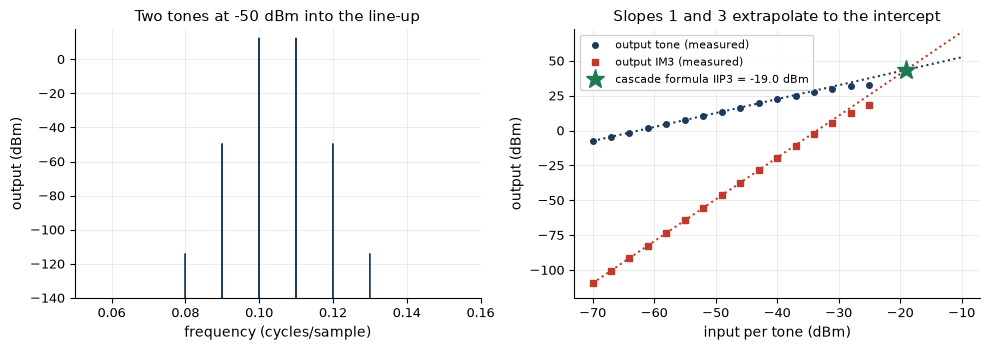

P_in (dBm),tone out (dBm),IM3 out (dBm),IIP3 = P_in + Δ/2 (dBm)
-70,-7.5,-109.5,-19.01
-61,1.5,-82.5,-19.01
-52,10.5,-55.5,-19.01
-43,19.4,-28.6,-19.00
-34,27.7,-2.5,-18.90
-25,32.5,18.0,-17.74


In [3]:
def iip3_demo(pin_dbm=-50.0, lna_iip3=-10.0, mix_iip3=5.0, bb_oip3=45.0, vga_gain=30.0):
    # the baseband stage keeps its OUTPUT intercept when the VGA gain changes, so its input intercept is OIP3 - gain
    st = [("T/R switch, balun", -2.5, 2.5, None), ("LNA", 20.0, 1.5, lna_iip3), ("mixer + TIA", 15.0, 10.0, mix_iip3), ("BB filter + VGA", vga_gain, 20.0, bb_oip3 - vga_gain)]
    stages = [rf.poly_stage(g, ip) for _, g, _, ip in st]
    system = lambda x: stages[3](stages[2](stages[1](stages[0](x))))
    n = 1 << 14
    t = np.arange(n); f1, f2 = 1638 / n, 1802 / n
    A = np.sqrt(2 * 10 ** (pin_dbm / 10))
    y = system(A * (np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)))
    Y = rf.db10(np.abs(np.fft.rfft(y) / n * 2) ** 2 / 2)
    pins = np.arange(-70, -24, 3.0)
    meas = np.array([rf.two_tone(system, p_) for p_ in pins])
    form = rf.cascade(st)
    fig, ax = lk.fig("row2", 1, 2)
    fr = np.fft.rfftfreq(n)
    ax[0].plot(fr, Y, color=lk.NAVY, lw=0.8); ax[0].set_xlim(0.05, 0.16); ax[0].set_ylim(-140, max(Y) + 5)
    ax[0].set_xlabel("frequency (cycles/sample)"); ax[0].set_ylabel("output (dBm)"); ax[0].set_title(f"Two tones at {pin_dbm:g} dBm into the line-up")
    G = form[-1][1]
    ax[1].plot(pins, meas[:, 0], "o", color=lk.NAVY, ms=4, label="output tone (measured)")
    ax[1].plot(pins, meas[:, 1], "s", color=lk.RED, ms=4, label="output IM3 (measured)")
    pp = np.linspace(-70, -10, 100); ip = form[-1][3]
    ax[1].plot(pp, pp + G, ":", color=lk.NAVY); ax[1].plot(pp, 3 * pp - 2 * ip + G, ":", color=lk.RED)
    ax[1].plot(ip, ip + G, "*", ms=14, color=lk.GREEN, label=f"cascade formula IIP3 = {ip:.1f} dBm")
    ax[1].set_xlabel("input per tone (dBm)"); ax[1].set_ylabel("output (dBm)"); ax[1].legend(fontsize=8); ax[1].set_ylim(-120, G + 10)
    ax[1].set_title("Slopes 1 and 3 extrapolate to the intercept")
    lk.show(fig)
    lk.table([[f"{p_:.0f}", f"{m_[0]:.1f}", f"{m_[1]:.1f}", f"{m_[2]:.2f}"] for p_, m_ in zip(pins[::3], meas[::3])],
             ["P_in (dBm)", "tone out (dBm)", "IM3 out (dBm)", "IIP3 = P_in + Δ/2 (dBm)"], title=f"Measured; cascade formula gives {ip:.2f} dBm")

lk.interact(iip3_demo, pin_dbm=lk.slider(-50, -70, -20, 1, "input per tone (dBm)"), lna_iip3=lk.slider(-10, -20, 10, 1, "LNA IIP3 (dBm)"),
            mix_iip3=lk.slider(5, -10, 20, 1, "mixer IIP3 (dBm)"), bb_oip3=lk.slider(45, 30, 60, 1, "baseband OIP3 (dBm)"),
            vga_gain=lk.slider(30, 0, 40, 1, "VGA gain (dB)"))

**What you should see.** The measured IIP3 is −19.0 dBm at every low drive level, exactly the cascade formula: the IM3 products of the
stages really do add in phase here, because every cubic coefficient has the same sign. At high drive the points bend away from the
slope-3 line (compression) and the single-point estimate becomes optimistic. Lower the VGA gain by 10 dB (to 20 dB): the cascade IIP3 rises
to about −15 dBm, as in the chapter, because the baseband stage, which dominates, now sees 10 dB less signal.

### Try it yourself 1.1
A single stage shows IM3 products 60 dB below two −30 dBm tones. What is its IIP3 (dBm)?

In [5]:
answer_1_1 = None
lk.check("1.1 IIP3 (dBm)", answer_1_1, -30 + 30, atol=0.1)

[TODO] 1.1 IIP3 (dBm): not attempted yet: replace the None with your answer

## 2. A receiver line-up calculator and SFDR

A line-up table carries, stage by stage, the cumulative gain, noise figure (Friis) and IIP3. The **spurious-free dynamic range** in a
bandwidth $B$ is the range of input levels over which a signal is above the noise floor while IM3 stays below it:
$\mathrm{SFDR} = \tfrac23(\mathrm{IIP3} - N_{floor})$ with $N_{floor} = -174 + 10\log_{10}B + \mathrm{NF}$. Chapter 7's example: NF 4.36 dB,
IIP3 −19.0 dBm, SFDR 60 dB in 1 MHz. Noise wants gain early; linearity wants gain late: the LNA gain that maximises SFDR is a compromise.

### Interactive: edit the line-up

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

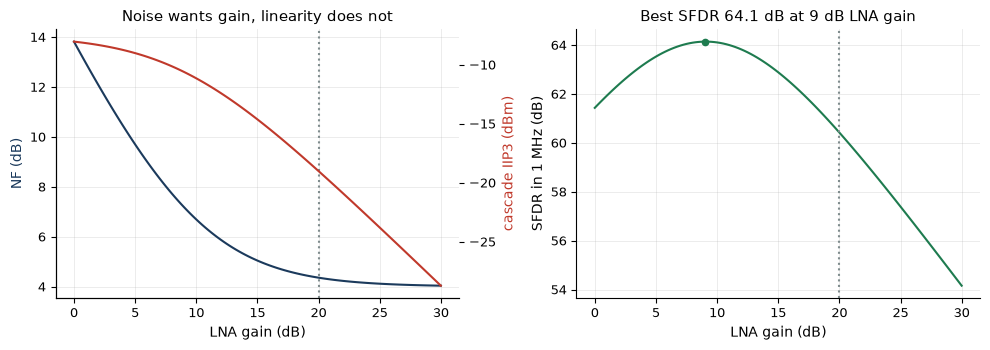

stage,cum. gain (dB),cum. NF (dB),cum. IIP3 (dBm)
"T/R switch, balun",-2.5,2.50,—
LNA,17.5,4.00,-7.5
mixer + TIA,32.5,4.27,-13.7
BB filter + VGA,62.5,4.36,-19.0


,
noise floor in the bandwidth,-109.6 dBm
SFDR = 2/3 (IIP3 − floor),60.4 dB
IM3 at the floor needs two tones of,-49.2 dBm each


In [7]:
def lineup_demo(loss_db=2.5, lna_gain=20.0, lna_nf=1.5, lna_iip3=-10.0, mix_nf=10.0, vga_gain=30.0, bw_hz=1e6):
    st = [("T/R switch, balun", -loss_db, loss_db, None), ("LNA", lna_gain, lna_nf, lna_iip3), ("mixer + TIA", 15.0, mix_nf, 5.0), ("BB filter + VGA", vga_gain, 20.0, 45.0 - vga_gain)]
    rows = rf.cascade(st)
    nf, ip = rows[-1][2], rows[-1][3]
    floor = rf.K_DBM + 10 * np.log10(bw_hz) + nf
    sfdr = 2 / 3 * (ip - floor)
    Gl = np.linspace(0, 30, 121); NF, IP, SF = [], [], []
    for g in Gl:
        c = rf.cascade([st[0], ("LNA", g, lna_nf, lna_iip3), st[2], st[3]])[-1]
        NF.append(c[2]); IP.append(c[3]); SF.append(2 / 3 * (c[3] - (rf.K_DBM + 10 * np.log10(bw_hz) + c[2])))
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].plot(Gl, NF, color=lk.NAVY, label="cascade NF (dB)"); a2 = ax[0].twinx(); a2.plot(Gl, IP, color=lk.RED); a2.set_ylabel("cascade IIP3 (dBm)", color=lk.RED); a2.grid(False)
    ax[0].axvline(lna_gain, color=lk.GRAY, ls=":"); ax[0].set_xlabel("LNA gain (dB)"); ax[0].set_ylabel("NF (dB)", color=lk.NAVY); ax[0].set_title("Noise wants gain, linearity does not")
    k = int(np.argmax(SF))
    ax[1].plot(Gl, SF, color=lk.GREEN); ax[1].plot(Gl[k], SF[k], "o", color=lk.GREEN); ax[1].axvline(lna_gain, color=lk.GRAY, ls=":")
    ax[1].set_xlabel("LNA gain (dB)"); ax[1].set_ylabel(f"SFDR in {bw_hz / 1e6:g} MHz (dB)"); ax[1].set_title(f"Best SFDR {SF[k]:.1f} dB at {Gl[k]:.0f} dB LNA gain")
    lk.show(fig)
    lk.table([[nm, f"{g:.1f}", f"{n_:.2f}", "—" if not np.isfinite(i_) else f"{i_:.1f}"] for nm, g, n_, i_ in rows],
             ["stage", "cum. gain (dB)", "cum. NF (dB)", "cum. IIP3 (dBm)"])
    lk.table([["noise floor in the bandwidth", f"{floor:.1f} dBm"], ["SFDR = 2/3 (IIP3 − floor)", f"{sfdr:.1f} dB"],
              ["IM3 at the floor needs two tones of", f"{(2 * ip + floor) / 3:.1f} dBm each"]], ["", ""])

lk.interact(lineup_demo, loss_db=lk.slider(2.5, 0, 5, 0.1, "loss before the LNA (dB)"), lna_gain=lk.slider(20, 0, 30, 1, "LNA gain (dB)"),
            lna_nf=lk.slider(1.5, 0.5, 4, 0.1, "LNA NF (dB)"), lna_iip3=lk.slider(-10, -25, 10, 1, "LNA IIP3 (dBm)"),
            mix_nf=lk.slider(10, 5, 16, 0.5, "mixer NF (dB)"), vga_gain=lk.slider(30, 0, 40, 1, "VGA gain (dB)"),
            bw_hz=lk.choice([200e3, 1e6, 20e6], 1e6, "bandwidth (Hz)"))

**What you should see.** The defaults reproduce the chapter's table: cumulative NF 2.5, 4.0, 4.27, 4.36 dB and IIP3 −7.5, −13.7, −19.0 dBm;
a −109.6 dBm floor in 1 MHz and an SFDR of 60 dB. The trade-off panel shows NF falling and IIP3 falling as the LNA gain rises, with an
SFDR optimum. Reduce the VGA gain to 20 dB: IIP3 improves by about 4 dB for a fraction of a dB of NF, the logic of a gain table.

### Try it yourself 2.1
What is the SFDR (dB) in 200 kHz for NF = 5 dB and IIP3 = −10 dBm?

In [9]:
answer_2_1 = None
lk.check("2.1 SFDR in 200 kHz (dB)", answer_2_1, 2 / 3 * (-10 - (-174 + 10 * np.log10(200e3) + 5)), atol=0.1)

[TODO] 2.1 SFDR in 200 kHz (dB): not attempted yet: replace the None with your answer

## 3. Phase noise from a mask, jitter and reciprocal mixing

An oscillator's phase noise is specified as $\mathcal L(f)$, the single-sideband noise power per hertz relative to the carrier at offset
$f$. Integrating it gives the RMS phase error, $\sigma_\phi = \sqrt{2\int\mathcal L(f)\,df}$, which smears constellations. And a strong
**blocker** near the wanted channel is mixed by the noisy LO onto the wanted frequency: **reciprocal mixing** adds
$P_b + \mathcal L(\Delta f) + 10\log_{10}B$ of noise. Chapter 7: a −40 dBm blocker 1 MHz away with $\mathcal L(1\,\mathrm{MHz}) = -100$
dBc/Hz puts −87 dBm into a 200 kHz channel whose thermal floor is −116 dBm: 29 dB of desensitisation. Below, phase noise is synthesised
from a mask (by shaping white noise in frequency), applied to a blocker, and the noise landing in the wanted channel is measured.

### Interactive: the mask and the blocker

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

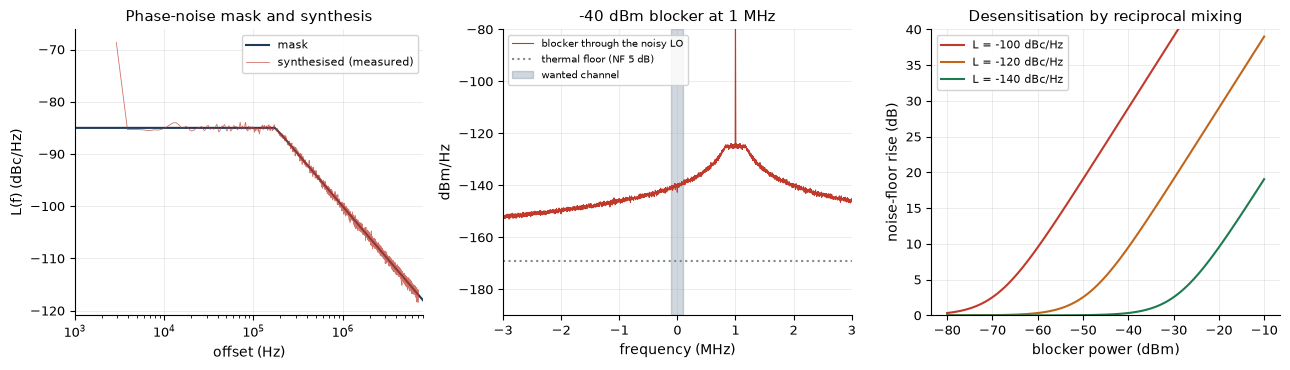

,
"RMS phase error, 1 kHz – 8 MHz (from the mask)",2.70°
RMS phase of the synthesised φ(t),2.71°
reciprocal-mixing noise in 200 kHz: measured,-87.0 dBm
… predicted P_b + L + 10 log B,-87.0 dBm
thermal floor in 200 kHz (NF 5 dB),-116.0 dBm
L(1 MHz) needed for −10 dB below thermal at −40 dBm,-139 dBc/Hz


PLL loop bandwidth,RMS phase error 1 kHz–10 MHz
50 kHz,1.29°
200 kHz,0.46°
400 kHz,0.35°
800 kHz,0.35°


In [11]:
def pn_demo(L1M=-100.0, slope=20.0, floor=-150.0, plateau=-85.0, blocker_dbm=-40.0, offset_mhz=1.0):
    fs, n = 16e6, 1 << 20
    mf = np.logspace(2, np.log10(fs / 2), 60)
    md = np.maximum(np.minimum(L1M - slope * np.log10(mf / 1e6), plateau), floor)          # PLL-like: flat in-band plateau
    r = np.random.default_rng(3)
    phi = rf.phase_noise_from_mask(n, fs, mf, md, r)
    t = np.arange(n) / fs
    blk = np.sqrt(10 ** (blocker_dbm / 10)) * np.exp(2j * np.pi * offset_mhz * 1e6 * t + 1j * phi)   # complex baseband, power in mW
    B, nf = 200e3, 5.0
    f, P = sps.welch(blk, fs, nperseg=1 << 14, return_onesided=False, window="blackmanharris")
    f, P = np.fft.fftshift(f), np.fft.fftshift(P)
    inband = np.sum(P[np.abs(f) < B / 2]) * (f[1] - f[0])
    thermal = rf.K_DBM + 10 * np.log10(B) + nf
    predicted = blocker_dbm + float(np.interp(np.log10(offset_mhz * 1e6), np.log10(mf), md)) + 10 * np.log10(B)
    fig, ax = lk.fig((13, 3.8), 1, 3)
    ax[0].semilogx(mf, md, color=lk.NAVY, label="mask"); fo = np.abs(f - offset_mhz * 1e6)
    sel = (f > offset_mhz * 1e6) & (fo > 2e3)
    ax[0].semilogx(fo[sel], rf.db10(P[sel] / 10 ** (blocker_dbm / 10)), color=lk.RED, lw=0.6, alpha=0.7, label="synthesised (measured)")
    ax[0].set_xlabel("offset (Hz)"); ax[0].set_ylabel("L(f) (dBc/Hz)"); ax[0].legend(fontsize=8); ax[0].set_title("Phase-noise mask and synthesis")
    ax[0].set_xlim(1e3, fs / 2)
    ax[1].plot(f / 1e6, rf.db10(P) + 30 - 30, color=lk.RED, lw=0.8, label="blocker through the noisy LO")
    ax[1].axhline(thermal - 10 * np.log10(B), color=lk.GRAY, ls=":", label="thermal floor (NF 5 dB)")
    ax[1].axvspan(-B / 2e6, B / 2e6, color=lk.NAVY, alpha=0.2, label="wanted channel")
    ax[1].set_xlim(-3, 3); ax[1].set_ylim(-190, blocker_dbm - 40); ax[1].set_xlabel("frequency (MHz)"); ax[1].set_ylabel("dBm/Hz"); ax[1].legend(fontsize=7.5)
    ax[1].set_title(f"{blocker_dbm:g} dBm blocker at {offset_mhz:g} MHz")
    pb = np.linspace(-80, -10, 100); nth = thermal
    for Lv, col in [(-100, lk.RED), (-120, lk.ORANGE), (-140, lk.GREEN)]:
        ax[2].plot(pb, rf.db10(10 ** ((pb + Lv + 10 * np.log10(B)) / 10) + 10 ** (nth / 10)) - nth, color=col, label=f"L = {Lv} dBc/Hz")
    ax[2].set_ylim(0, 40); ax[2].set_xlabel("blocker power (dBm)"); ax[2].set_ylabel("noise-floor rise (dB)"); ax[2].legend(fontsize=8)
    ax[2].set_title("Desensitisation by reciprocal mixing")
    lk.show(fig)
    ff = np.logspace(3, 7, 2000)
    lk.table([["RMS phase error, 1 kHz – 8 MHz (from the mask)", f"{rf.rms_phase_deg(ff[ff < fs / 2], np.interp(np.log10(ff[ff < fs / 2]), np.log10(mf), md)):.2f}°"],
              ["RMS phase of the synthesised φ(t)", f"{np.rad2deg(np.std(phi)):.2f}°"],
              ["reciprocal-mixing noise in 200 kHz: measured", f"{rf.db10(inband):.1f} dBm"], ["… predicted P_b + L + 10 log B", f"{predicted:.1f} dBm"],
              ["thermal floor in 200 kHz (NF 5 dB)", f"{thermal:.1f} dBm"],
              ["L(1 MHz) needed for −10 dB below thermal at −40 dBm", f"{thermal - 10 - (-40) - 10 * np.log10(B):.0f} dBc/Hz"]], ["", ""])

lk.interact(pn_demo, L1M=lk.slider(-100, -150, -80, 1, "L at 1 MHz (dBc/Hz)"), slope=lk.choice([20.0, 30.0], 20.0, "slope (dB/decade)"),
            floor=lk.slider(-150, -170, -130, 1, "floor (dBc/Hz)"), plateau=lk.slider(-85, -110, -70, 1, "in-band plateau (dBc/Hz)"), blocker_dbm=lk.slider(-40, -80, -10, 1, "blocker (dBm)"),
            offset_mhz=lk.slider(1.0, 0.3, 3.0, 0.1, "blocker offset (MHz)"))

f_ = np.logspace(3, 7, 2000)
*_, tot = rf.pll_components(f_)
lk.table([[f"{bw / 1e3:.0f} kHz", f"{rf.rms_phase_deg(f_, rf.pll_components(f_, fbw=bw)[-1]):.2f}°"] for bw in (50e3, 200e3, 400e3, 800e3)],
         ["PLL loop bandwidth", "RMS phase error 1 kHz–10 MHz"], title="Chapter 7's 2.4 GHz synthesiser (N = 60, 40 MHz reference)")

**What you should see.** The synthesised phase noise follows the mask; the blocker's skirt, offset by 1 MHz, lays noise across the wanted
channel at the level the formula predicts, about −87 dBm against a −116 dBm thermal floor: the chapter's 29 dB of desensitisation; the
chapter's requirement for only 0.4 dB of loss is −139 dBc/Hz at 1 MHz. Lower the mask to −140 dBc/Hz and the skirt sinks below the floor.
The PLL table reproduces the chapter: about 0.35° RMS with a 400 kHz loop, rising to 1.3° with 50 kHz, where the noisy VCO is no longer
cleaned up by the loop.

### Try it yourself 3.1
A −30 dBm blocker 2 MHz away, an LO with −130 dBc/Hz at 2 MHz, a 1 MHz channel: what reciprocal-mixing noise (dBm)?

In [13]:
answer_3_1 = None
lk.check("3.1 reciprocal-mixing noise (dBm)", answer_3_1, -30 - 130 + 60, atol=0.1)

[TODO] 3.1 reciprocal-mixing noise (dBm): not attempted yet: replace the None with your answer

## 4. PA classes, Doherty and envelope tracking

An ideal class-A amplifier has efficiency $v^2/2$ at normalised output amplitude $v$, class B $\pi v/4$ (78.5% at peak). A signal with
PAPR of 8 dB spends most of its time well below peak, where both are poor. The **Doherty** amplifier modulates its main device's load with
a second "peaking" device that turns on above a fraction $\alpha$ of full drive: a symmetric Doherty ($\alpha = 1/2$) has two efficiency
peaks of 78.5%, at full power and at 6 dB back-off; a 1:2 asymmetric one ($\alpha = 1/3$) at 9.5 dB. **Envelope tracking** varies the supply
with the envelope. Chapter 7 compares them on an OFDM envelope clipped to 8 dB PAPR.

### Interactive: PAPR and the Doherty split

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

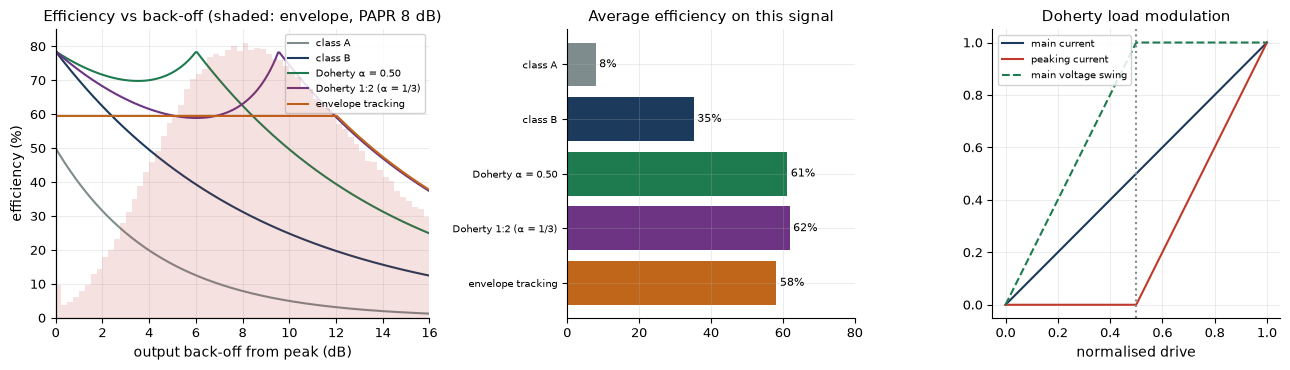

amplifier,average efficiency,DC power for 40 W,heat
class A,8%,506 W,466 W
class B,35%,114 W,74 W
Doherty α = 0.50,61%,65 W,25 W
Doherty 1:2 (α = 1/3),62%,65 W,25 W
envelope tracking,58%,69 W,29 W


In [15]:
def pa_demo(papr_db=8.0, alpha=0.5):
    r = np.random.default_rng(41)
    x = (r.standard_normal(400_000) + 1j * r.standard_normal(400_000)) / np.sqrt(2)
    A = 10 ** (papr_db / 20); a = np.abs(x); x = np.where(a > A, x / np.maximum(a, 1e-12) * A, x)
    v = np.abs(x) / np.abs(x).max()
    curves = [("class A", rf.eff_class_a, lk.GRAY), ("class B", rf.eff_class_b, lk.NAVY), (f"Doherty α = {alpha:.2f}", lambda u: rf.eff_doherty(u, alpha), lk.GREEN),
              ("Doherty 1:2 (α = 1/3)", lambda u: rf.eff_doherty(u, 1 / 3), lk.PURPLE), ("envelope tracking", rf.eff_et, lk.ORANGE)]
    obo = np.linspace(0, 16, 300); vv = 10 ** (-obo / 20)
    fig, ax = lk.fig((13, 3.8), 1, 3, gridspec_kw=dict(width_ratios=[1.3, 1, 1]))
    for lab, e, col in curves:
        ax[0].plot(obo, 100 * e(vv), color=col, label=lab)
    a2 = ax[0].twinx(); a2.hist(-20 * np.log10(v[v > 1e-3]), bins=120, range=(0, 30), density=True, color=lk.RED, alpha=0.15); a2.set_yticks([]); a2.grid(False)
    ax[0].set_xlim(0, 16); ax[0].set_ylim(0, 85); ax[0].set_xlabel("output back-off from peak (dB)"); ax[0].set_ylabel("efficiency (%)"); ax[0].legend(fontsize=7)
    ax[0].set_title(f"Efficiency vs back-off (shaded: envelope, PAPR {papr_db:g} dB)")
    vals = [100 * rf.avg_efficiency(e, v) for _, e, _ in curves]
    ax[1].barh(range(len(vals))[::-1], vals, color=[c for _, _, c in curves])
    for i, val in enumerate(vals):
        ax[1].text(val + 1, len(vals) - 1 - i, f"{val:.0f}%", va="center", fontsize=8)
    ax[1].set_yticks(range(len(vals))[::-1]); ax[1].set_yticklabels([c[0] for c in curves], fontsize=7.5); ax[1].set_xlim(0, 80)
    ax[1].set_title("Average efficiency on this signal")
    u = np.linspace(0, 1, 400)
    ax[2].plot(u, u, color=lk.NAVY, label="main current"); ax[2].plot(u, np.where(u < alpha, 0, (u - alpha) / (1 - alpha)), color=lk.RED, label="peaking current")
    ax[2].plot(u, np.where(u < alpha, u / alpha, 1.0), "--", color=lk.GREEN, label="main voltage swing"); ax[2].axvline(alpha, color=lk.GRAY, ls=":")
    ax[2].set_xlabel("normalised drive"); ax[2].legend(fontsize=7.5); ax[2].set_title("Doherty load modulation")
    lk.show(fig)
    P = 40.0
    lk.table([[c[0], f"{v_:.0f}%", f"{P / (v_ / 100):.0f} W", f"{P / (v_ / 100) - P:.0f} W"] for c, v_ in zip(curves, vals)],
             ["amplifier", "average efficiency", "DC power for 40 W", "heat"], title=f"OFDM with {papr_db:g} dB PAPR")

lk.interact(pa_demo, papr_db=lk.slider(8, 4, 12, 0.5, "PAPR after CFR (dB)"), alpha=lk.slider(0.5, 0.2, 0.8, 0.01, "Doherty transition α"))

**What you should see.** Class A wastes almost everything on an 8 dB PAPR signal; class B does better; the symmetric Doherty raises the
average further by holding its efficiency high across the 6 dB below peak where the OFDM envelope spends its time; the asymmetric 1:2
Doherty is about as good at 8 dB PAPR (its advantage grows at higher PAPR), and envelope tracking, limited here by an 85%-efficient
supply, lands a little below the Doherty. The heat column is what a 40 W base-station carrier dissipates: the reason
every macro cell uses a Doherty (Chapter 7's base-station example). Lower the PAPR (more aggressive crest-factor reduction): every
architecture gains, which is why CFR and efficient PAs go together.

## 5. Memory-polynomial DPD with indirect learning

A digital predistorter applies an approximate inverse of the PA so that the cascade is linear. Real PAs have **memory** (their response
depends on past samples: bias networks, matching, thermal effects), so the predistorter is a **memory polynomial**
$z[n] = \sum_{m=0}^{M}\sum_{k=1}^{K} c_{km}\,x[n-m]|x[n-m]|^{k-1}$. **Indirect learning** fits a *post*-inverse from the PA's output
(divided by the target gain) back to its input by least squares, then copies it in front of the PA, and iterates. Chapter 7: on a
Wiener–Hammerstein PA at 11 dB input back-off, the PA alone gives 39 dB ACLR, a memoryless polynomial ($K = 7$, $M = 0$) 56 dB, a memory
polynomial ($K = 7$, $M = 3$) 60 dB.

### Interactive: back-off, order and memory depth

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

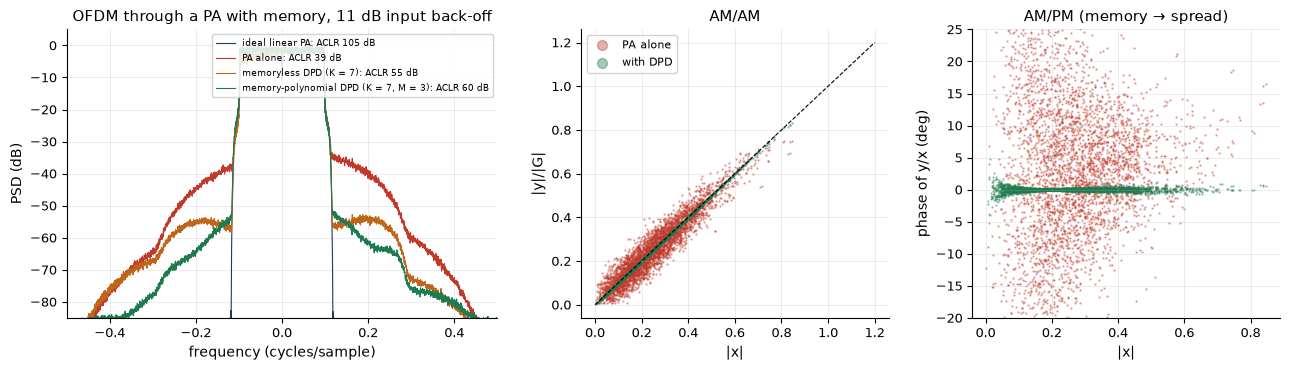

configuration,ACLR (dB)
ideal linear PA,105.2
PA alone,39.0
memoryless DPD (K = 7),54.7
"memory-polynomial DPD (K = 7, M = 3)",59.6


,
PAPR of the DPD output vs input,13.4 vs 10.5 dB
coefficients,28


In [17]:
def ofdm_signal(n_sym, r, n_used=200, nfft=1024, ncp=72):
    cfg = cl.OFDMConfig(nfft=nfft, n_used=n_used, ncp=ncp)
    g = cl.get_constellation("64qam").modulate(cl.random_bits(6 * n_used * n_sym, r)).reshape(n_sym, n_used)
    x = np.convolve(cl.ofdm_modulate(g, cfg), sps.firwin(301, 1.15 * n_used / nfft), mode="same")
    return x / np.sqrt(np.mean(np.abs(x) ** 2))

def aclr(x, bw, off, nper=4096):
    f, P = sps.welch(x, nperseg=nper, return_onesided=False, window="blackmanharris", detrend=False)
    main = P[np.abs(f) < bw / 2].sum(); up = P[np.abs(f - off) < bw / 2].sum(); lo = P[np.abs(f + off) < bw / 2].sum()
    return rf.db10(main / max(up, lo)), np.fft.fftshift(f), np.fft.fftshift(P)

def dpd_demo(ibo_db=11.0, K=7, M=3, iters=5, n_sym=120):
    r = np.random.default_rng(8)
    xin = ofdm_signal(n_sym, r) * 10 ** (-ibo_db / 20)
    G = np.vdot(0.01 * xin, rf.pa_memory(0.01 * xin)) / np.vdot(0.01 * xin, 0.01 * xin)
    y = rf.pa_memory(xin)
    _, y_ml = rf.ila_dpd(xin, rf.pa_memory, K=K, M=0, G=G, iters=iters)
    z_mp, y_mp = rf.ila_dpd(xin, rf.pa_memory, K=K, M=M, G=G, iters=iters)
    bw, off = 200 / 1024, 1.2 * 200 / 1024
    fig, ax = lk.fig((13, 3.8), 1, 3, gridspec_kw=dict(width_ratios=[1.4, 1, 1]))
    rows = []
    for sig, lab, col in [(G * xin, "ideal linear PA", lk.NAVY), (y, "PA alone", lk.RED), (y_ml, f"memoryless DPD (K = {K})", lk.ORANGE), (y_mp, f"memory-polynomial DPD (K = {K}, M = {M})", lk.GREEN)]:
        a_, f, P = aclr(sig, bw, off)
        ax[0].plot(f, rf.db10(P / P.max()), color=col, lw=0.8, label=f"{lab}: ACLR {a_:.0f} dB")
        rows.append([lab, a_])
    ax[0].set_xlim(-0.5, 0.5); ax[0].set_ylim(-85, 5); ax[0].legend(fontsize=6.8, loc="upper right"); ax[0].set_xlabel("frequency (cycles/sample)"); ax[0].set_ylabel("PSD (dB)")
    ax[0].set_title(f"OFDM through a PA with memory, {ibo_db:g} dB input back-off")
    sel = slice(5000, 9000)
    for yy, col, lab in [(y, lk.RED, "PA alone"), (y_mp, lk.GREEN, "with DPD")]:
        ax[1].scatter(np.abs(xin[sel]), np.abs(yy[sel]) / abs(G), s=0.5, color=col, alpha=0.4, label=lab, rasterized=True)
        ax[2].scatter(np.abs(xin[sel]), np.rad2deg(np.angle(yy[sel] / xin[sel] / (G / abs(G)))), s=0.5, color=col, alpha=0.4, rasterized=True)
    ax[1].plot([0, 1.2], [0, 1.2], "k--", lw=0.8); ax[1].set_xlabel("|x|"); ax[1].set_ylabel("|y|/|G|"); ax[1].legend(fontsize=8, markerscale=10); ax[1].set_title("AM/AM")
    ax[2].set_ylim(-20, 25); ax[2].set_xlabel("|x|"); ax[2].set_ylabel("phase of y/x (deg)"); ax[2].set_title("AM/PM (memory → spread)")
    lk.show(fig)
    lk.table(rows, ["configuration", "ACLR (dB)"], fmt=".1f")
    lk.table([["PAPR of the DPD output vs input", f"{rf.db10(np.max(np.abs(z_mp)) ** 2 / np.mean(np.abs(z_mp) ** 2)):.1f} vs {rf.db10(np.max(np.abs(xin)) ** 2 / np.mean(np.abs(xin) ** 2)):.1f} dB"],
              ["coefficients", K * (M + 1)]], ["", ""])

lk.interact(dpd_demo, ibo_db=lk.slider(11, 4, 20, 0.5, "input back-off (dB)"), K=lk.islider(7, 3, 9, 1, "nonlinearity order K"),
            M=lk.islider(3, 0, 6, 1, "memory depth M"), iters=lk.islider(5, 1, 10, 1, "ILA iterations"), n_sym=lk.choice([60, 120, 260], 120, "OFDM symbols"))

**What you should see.** The PA alone splatters into the adjacent channel (ACLR about 39 dB); the memoryless predistorter removes the
static AM/AM and AM/PM and gains about 15 dB; the memory polynomial removes most of the rest, close to 60 dB as in Chapter 7. The AM/AM
cloud collapses onto the diagonal and the AM/PM spread (the signature of memory) shrinks. Reduce the back-off to 6 dB: the PA is driven
into saturation, where no predistorter can add power that the device cannot deliver, and the gain of DPD shrinks; the predistorter also
raises the PAPR of the drive signal, which is why DPD is always paired with crest-factor reduction.

### Try it yourself 5.1
How many complex coefficients does a memory polynomial with $K = 5$ and $M = 4$ have?

In [19]:
answer_5_1 = None
lk.check("5.1 memory-polynomial coefficients", answer_5_1, 5 * 5, atol=0)

[TODO] 5.1 memory-polynomial coefficients: not attempted yet: replace the None with your answer

## Key takeaways
* IIP3 = P_in + Δ/2; in a cascade, reciprocals of input-referred intercepts add and the last high-gain stage often dominates.
* A line-up trades NF (wants early gain) against IIP3 (wants late gain); SFDR = ⅔(IIP3 − floor) measures the compromise.
* Phase noise integrates to RMS jitter and, through reciprocal mixing, turns out-of-channel blockers into in-channel noise.
* High-PAPR signals need Doherty or envelope-tracking PAs to be efficient; CFR helps every architecture.
* Memory-polynomial DPD with indirect learning linearises a PA with memory by 20 dB of ACLR.

## Going further (hardware: USRP B200 / GNU Radio)
* Combine two signal generators (or two B200 TX channels of a B210) through a combiner and attenuators into the B200's RX, and measure its IIP3
  at several gain settings: you are measuring the gain table of Section 2.
* Capture a strong FM broadcast station next to a weak one and see the strong one's reciprocal-mixing skirt with the B200's LO
  (`gnuradio/gr01_spectrum_iq_capture.py`).
* Transmit OFDM from the B200 through a small external PA into an attenuator and the receiver, then fit and apply `rf.ila_dpd`
  to the captured samples: real DPD on a real PA.

## Exercises
1. **(Warm-up)** Derive $\mathrm{IIP3} = P_{in} + \Delta/2$ from $y = a_1x + a_3x^3$ with two equal tones.
2. **(Core)** Give the cascade stages random IM3 phases (a complex $a_3$) and show that the measured IIP3 is better than the formula's worst case.
3. **(Core)** Add a 1/f³ region to the phase-noise mask and compute its effect on 256-QAM EVM through the common-phase-error tracking of Lab 28.
4. **(Stretch)** Implement a generalised memory polynomial (cross terms between $x[n-m]$ and $|x[n-m-l]|$) and compare its ACLR with Section 5.

In [21]:
lk.summary()

[good] Lab 36 finished in 4.8 s. Self-checks: 0 passed, 0 failed, 4 still to do.